<a href="https://colab.research.google.com/github/nobg0321/ABCD-A/blob/20250526/yolov8_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. 초기 환경 설정

In [ ]:
# YOLOv8 설치
!pip install ultralytics

In [ ]:
# 필요한 라이브러리 임포트
import os
from ultralytics import YOLO
import shutil
from google.colab import drive
from google.colab import files

In [ ]:
# 파일 선택기를 통한 업로드
uploaded = files.upload()

Saving Test.v1i.yolov8.zip to Test.v1i.yolov8.zip


In [ ]:
# dataset 폴더 생성 (없을 경우)
!mkdir -p /content/datasety

# zip 파일을 dataset 폴더에 압축 해제
!unzip /content/Test.v1i.yolov8.zip -d /content/dataset

Archive:  /content/Test.v1i.yolov8.zip
replace /content/dataset/README.dataset.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

다음 폴더 구조를 수정합니다.


content/




In [ ]:
# test/images 폴더 생성 (없다면)
!mkdir -p /content/test/images

# 모든 파일 복사
!cp /content/dataset/train/images/* /content/test/images/

In [ ]:
# test/images 폴더 생성 (없다면)
!mkdir -p /content/valid/images

# 모든 파일 복사
!cp /content/dataset/train/images/* /content/valid/images/

In [ ]:
#valid/labels 폴더 생성
!mkdir -p /content/valid/labels
!cp /content/dataset/train/labels/* /content/valid/labels/

In [ ]:
model = YOLO('yolov8l-seg.pt')  # nano 모델 사용 (n, s, m, l, x 중 선택)

In [ ]:
results = model.train(
    data='/content/dataset/data.yaml',  # 데이터셋 설정 파일
    epochs=50,                         # 학습 에폭 수
    imgsz=640,                         # 이미지 크기
    batch=16,                          # 배치 크기
    name='yolov8_custom',              # 프로젝트 이름
    project='/content/runs/train',     # 저장 경로
    patience=10,                       # Early stopping patience
    save=True,                         # 체크포인트 저장
    device=0                           # GPU 사용
)

Ultralytics 8.3.145 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8_custom7, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=0.0, plots=True, pose=12.0, pre

train: Scanning /content/dataset/train/labels.cache... 16 images, 1 backgrounds, 0 corrupt: 100%|██████████| 16/16 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 306.9±150.6 MB/s, size: 21.3 KB)


val: Scanning /content/valid/labels... 16 images, 1 backgrounds, 0 corrupt: 100%|██████████| 16/16 [00:00<00:00, 208.08it/s]

...


50 epochs completed in 0.134 hours.
Optimizer stripped from /content/runs/train/yolov8_custom7/weights/last.pt, 92.3MB
Optimizer stripped from /content/runs/train/yolov8_custom7/weights/best.pt, 92.3MB

Validating /content/runs/train/yolov8_custom7/weights/best.pt...
Ultralytics 8.3.145 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8l-seg summary (fused): 125 layers, 45,916,514 parameters, 0 gradients, 220.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95):   0%|          | 0/1 [00:00<?, ?it/s]

WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  1.59it/s]


                   all         16        106      0.941      0.703      0.816       0.69      0.934        0.7      0.793      0.555
           dotted-line         12         57      0.962      0.444      0.862      0.672      0.924      0.427      0.722      0.457
             left-lane          1          1          1          0      0.166      0.166          1          0      0.166      0.116
             left_lane         14         14      0.963      0.929      0.959      0.829      0.963      0.929      0.959      0.761
             left_line         15         16      0.991      0.938      0.958      0.824      0.991      0.938      0.962       0.56
            right_lane         11         11      0.887      0.909      0.957      0.831      0.887      0.909      0.957      0.659
            right_line          7          7      0.841          1      0.995      0.819      0.841          1      0.995      0.773
Speed: 0.3ms preprocess, 21.3ms inference, 0.0ms loss, 3.1ms postproc

In [ ]:
# 가장 최근 학습된 모델 로드 (yolov8_custom의 best.pt 사용)
model = YOLO('/content/runs/train/yolov8_custom/weights/best.pt')

# 테스트 실행
results = model.predict(
    source='/content/dataset/test/images',  # 테스트 이미지 경로
    save=True,                              # 결과 저장
    save_txt=True,                          # 텍스트 결과도 저장
    conf=0.5,                               # 신뢰도 임계값
    project='/content/runs/detect',         # 저장 프로젝트 경로
    name='test_results'                     # 폴더 이름 지정
)

print("예측 완료!")
print(f"결과 저장 위치: /content/runs/detect/test_results/")

# 결과 확인
!ls -la /content/runs/detect/test_results/


image 1/16 /content/dataset/test/images/166-_jpg.rf.fa8176f5d28842bf2f6ecf187c8aafdf.jpg: 640x640 2 left_lanes, 1 left_line, 70.0ms
image 2/16 /content/dataset/test/images/167-_jpg.rf.c4983fe84b3f24f02d0a5a355d84e0ce.jpg: 640x640 3 dotted-lines, 1 left_lane, 1 left_line, 1 right_lane, 1 right_line, 70.0ms
image 3/16 /content/dataset/test/images/168-_jpg.rf.eca8176bdb7eeeda61f154d29f3f9d11.jpg: 640x640 2 left_lanes, 1 left_line, 42.4ms
image 4/16 /content/dataset/test/images/169-_jpg.rf.502e8e5691e6cdfeb53f4b27c70b3eaf.jpg: 640x640 4 dotted-lines, 1 left_lane, 1 left_line, 1 right_lane, 2 right_lines, 42.4ms
image 5/16 /content/dataset/test/images/17-_jpg.rf.99951403b338e1b298636aee1cb56a8f.jpg: 640x640 2 dotted-lines, 1 left_lane, 1 right_lane, 42.3ms
image 6/16 /content/dataset/test/images/170-_jpg.rf.d06389d021e240e1572ef3fdcca8460d.jpg: 640x640 2 left_lanes, 1 left_line, 38.1ms
image 7/16 /content/dataset/test/images/171-_jpg.rf.3451dfb4bc8a34211aa54a693f9e3d3b.jpg: 640x640 4 dotte

In [ ]:
import cv2

def draw_enhanced_results(image_path, results):
    """세그멘테이션 마스크를 이미지 위에 시각화"""
    # 이미지 로드
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 클래스 색상 정의
    class_names = ['dotted-line', 'left_lane', 'left_line', 'right_lane', 'right_line']
    colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255)]

    for result in results:
        masks = result.masks  # 마스크 객체

        if masks is not None and masks.data is not None:
            mask_data = masks.data.cpu().numpy()  # (N, H, W)
            cls_list = result.boxes.cls.cpu().numpy().astype(int)  # 클래스 인덱스 리스트
            conf_list = result.boxes.conf.cpu().numpy()  # 신뢰도

            for i in range(len(mask_data)):
                mask = mask_data[i]
                cls_id = cls_list[i]
                conf = conf_list[i]

                # 마스크 색상 및 클래스 이름
                color = colors[cls_id % len(colors)]
                class_name = class_names[cls_id] if cls_id < len(class_names) else f'class_{cls_id}'
                label = f'{class_name}: {conf:.2f}'

                # 마스크를 컬러로 적용
                colored_mask = np.zeros_like(img_rgb, dtype=np.uint8)
                for c in range(3):
                    colored_mask[:, :, c] = mask * color[c]

                # 반투명하게 overlay
                img_rgb = cv2.addWeighted(img_rgb, 1.0, colored_mask, 0.4, 0)

                # 마스크 경계 추출하여 텍스트 위치 추정
                contours, _ = cv2.findContours((mask * 255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                if contours:
                    x, y, w, h = cv2.boundingRect(contours[0])
                    # 라벨 텍스트
                    (text_width, text_height), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
                    cv2.rectangle(img_rgb, (x, y - text_height - 10), (x + text_width, y), color, -1)
                    cv2.putText(img_rgb, label, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    return img_rgb

Results saved to /content/runs/detect/test_results12
16 labels saved to /content/runs/detect/test_results12/labels


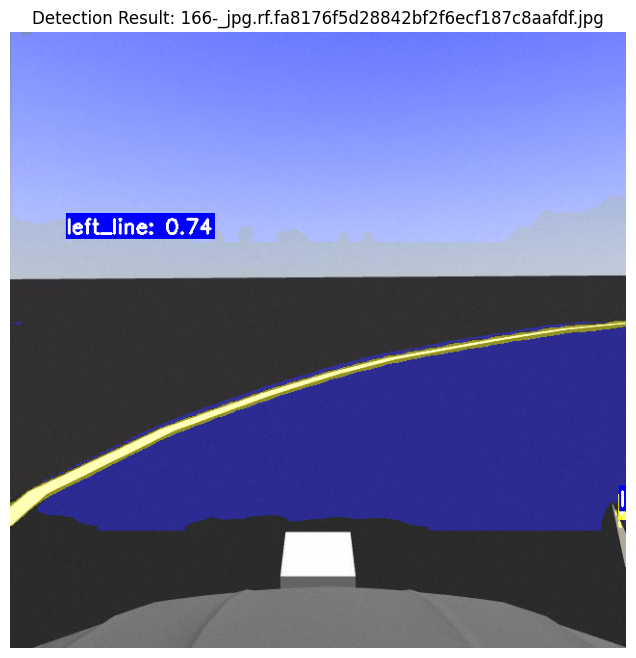

Results saved to /content/runs/detect/test_results12
16 labels saved to /content/runs/detect/test_results12/labels


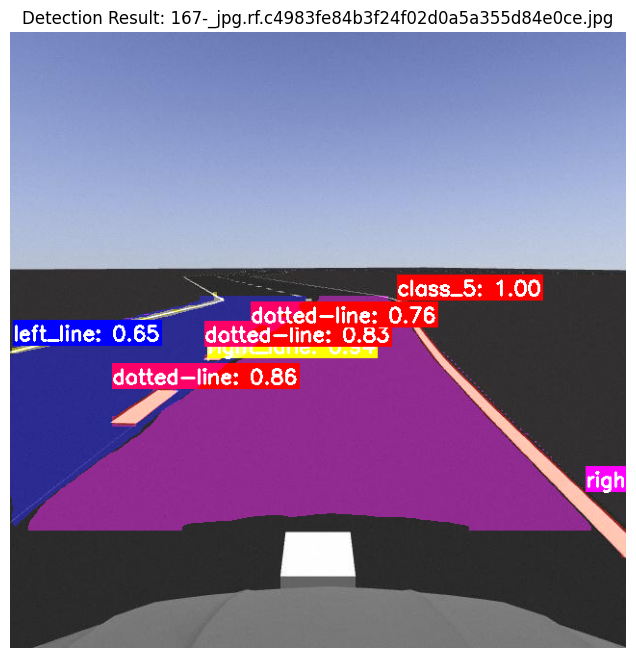

Results saved to /content/runs/detect/test_results12
16 labels saved to /content/runs/detect/test_results12/labels


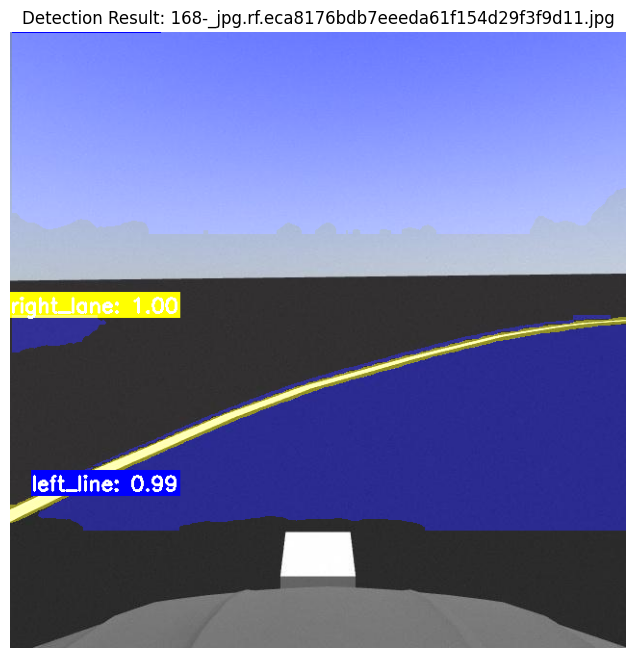

Results saved to /content/runs/detect/test_results12
16 labels saved to /content/runs/detect/test_results12/labels


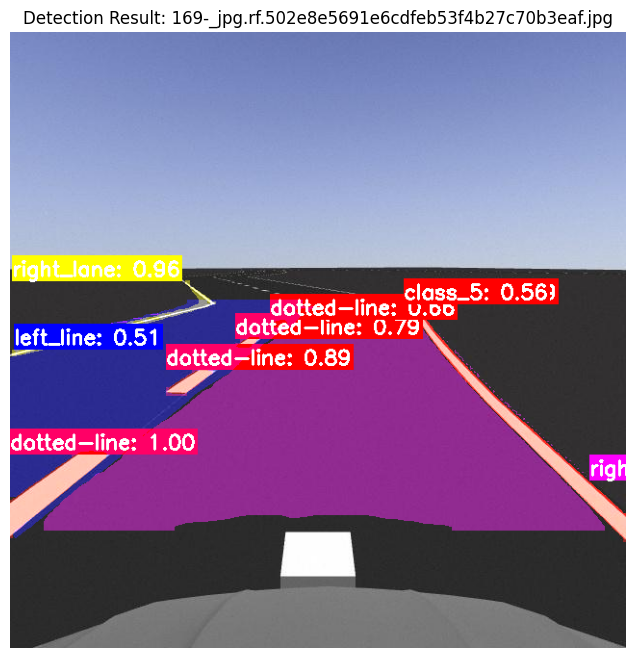

Results saved to /content/runs/detect/test_results12
16 labels saved to /content/runs/detect/test_results12/labels


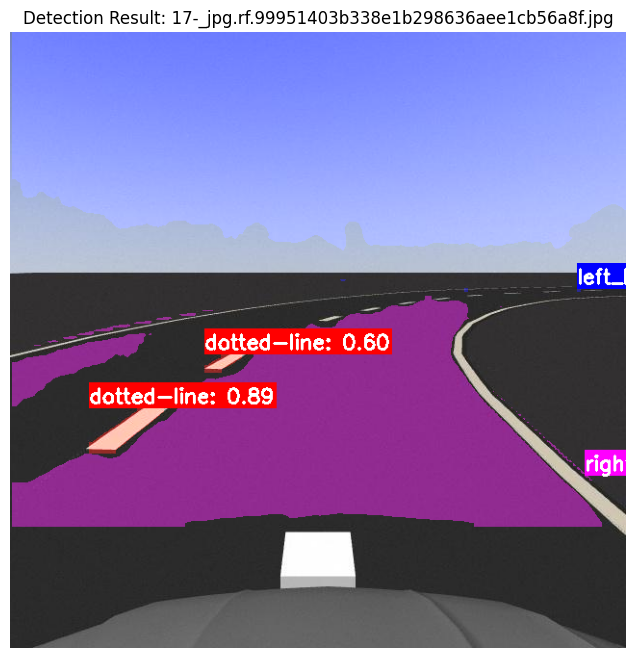

Results saved to /content/runs/detect/test_results12
16 labels saved to /content/runs/detect/test_results12/labels


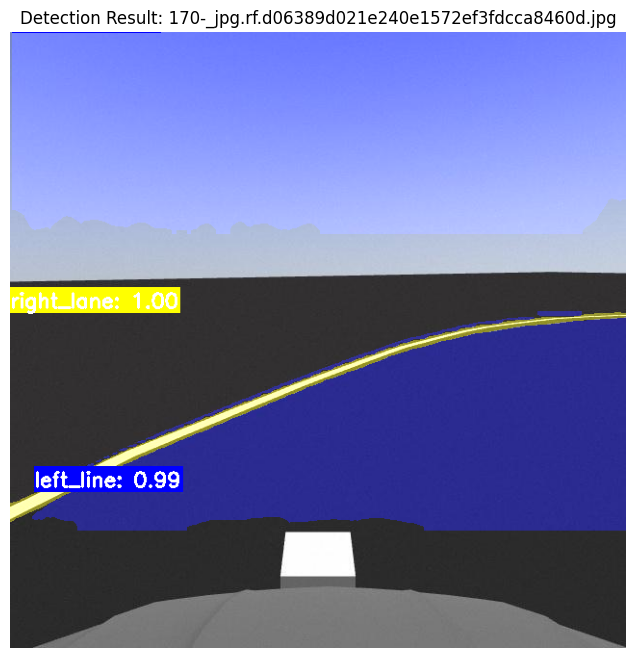

Results saved to /content/runs/detect/test_results12
16 labels saved to /content/runs/detect/test_results12/labels


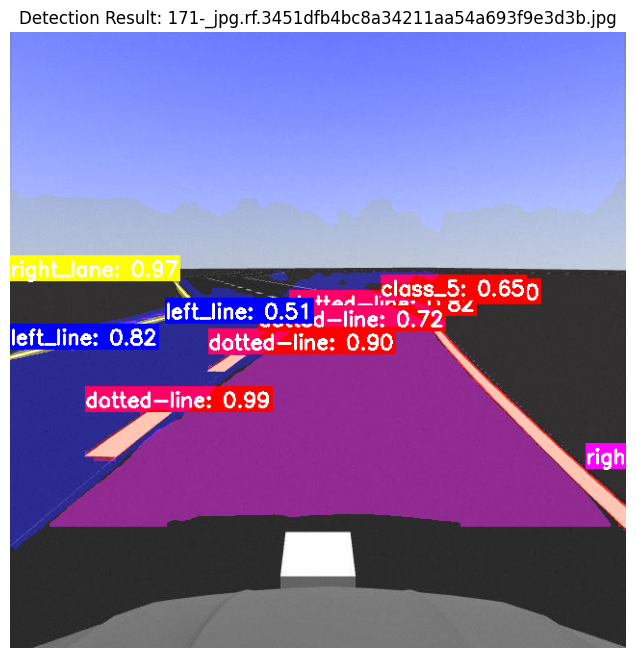

Results saved to /content/runs/detect/test_results12
16 labels saved to /content/runs/detect/test_results12/labels


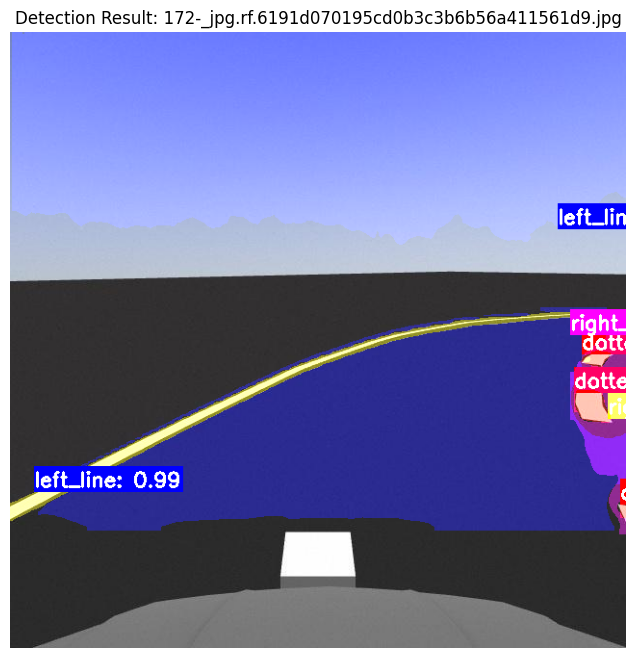

Results saved to /content/runs/detect/test_results12
16 labels saved to /content/runs/detect/test_results12/labels


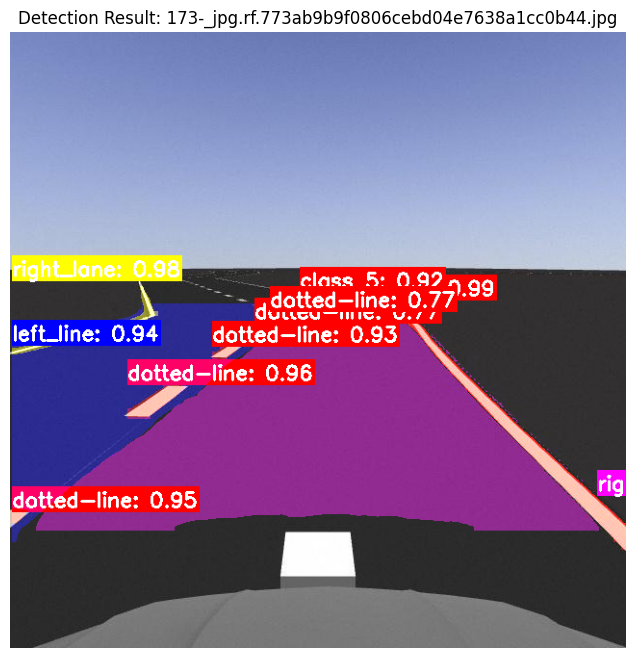

Results saved to /content/runs/detect/test_results12
16 labels saved to /content/runs/detect/test_results12/labels


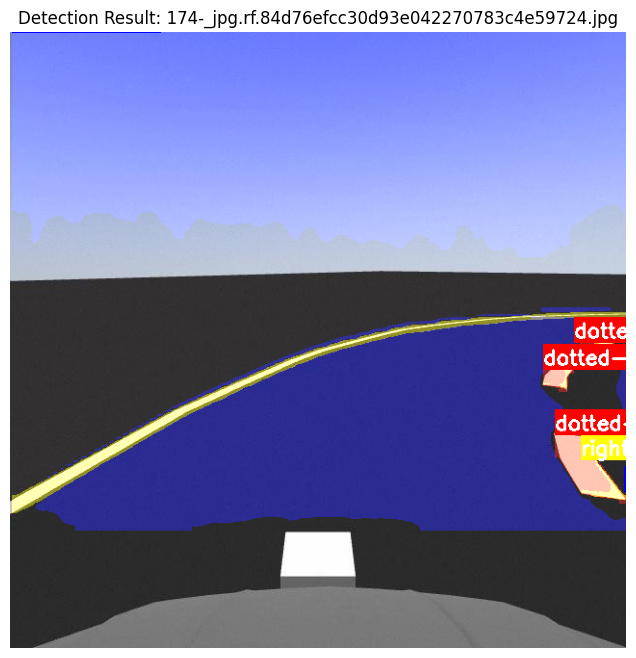

Results saved to /content/runs/detect/test_results12
16 labels saved to /content/runs/detect/test_results12/labels


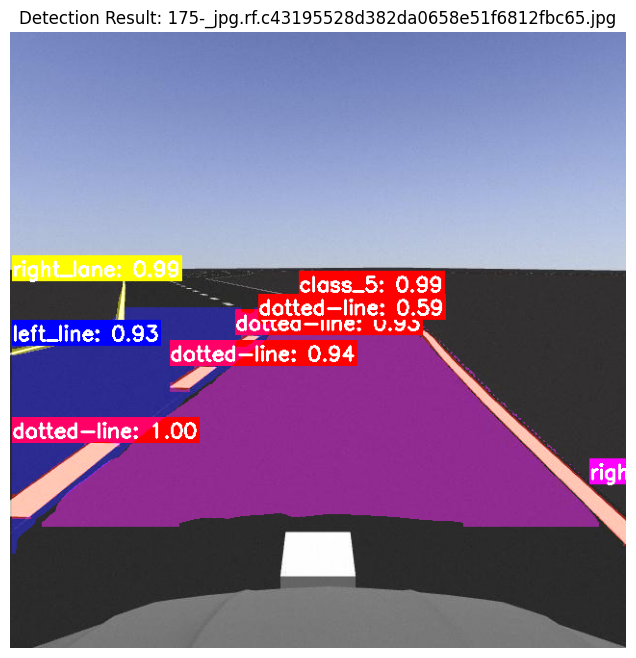

Results saved to /content/runs/detect/test_results12
16 labels saved to /content/runs/detect/test_results12/labels


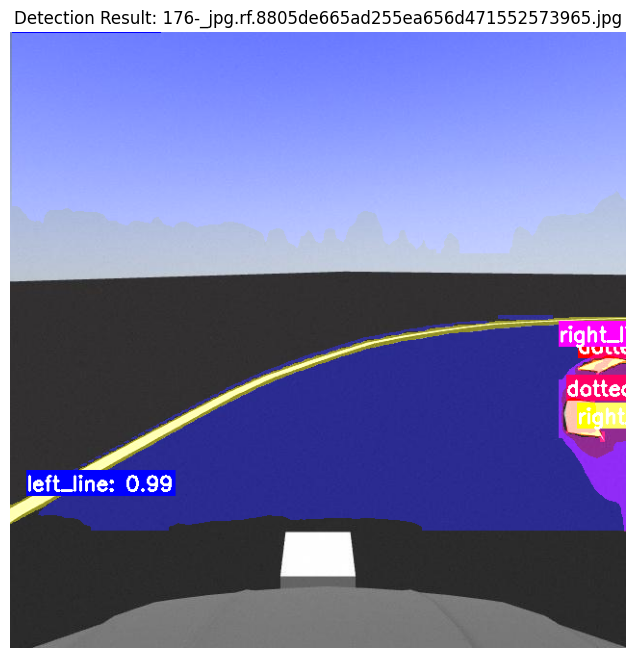

Results saved to /content/runs/detect/test_results12
16 labels saved to /content/runs/detect/test_results12/labels


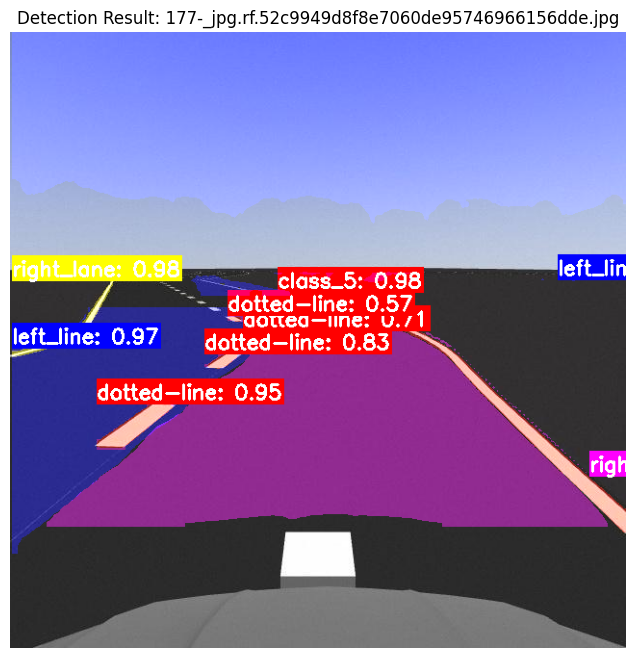

Results saved to /content/runs/detect/test_results12
16 labels saved to /content/runs/detect/test_results12/labels


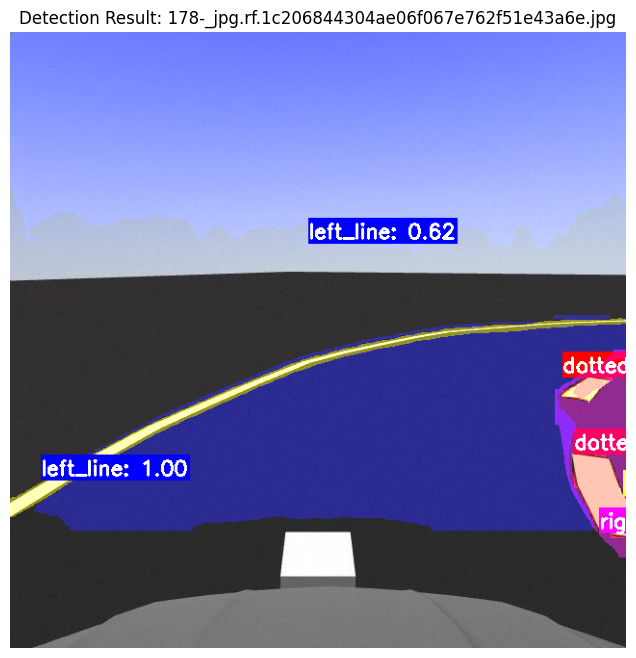

Results saved to /content/runs/detect/test_results12
16 labels saved to /content/runs/detect/test_results12/labels


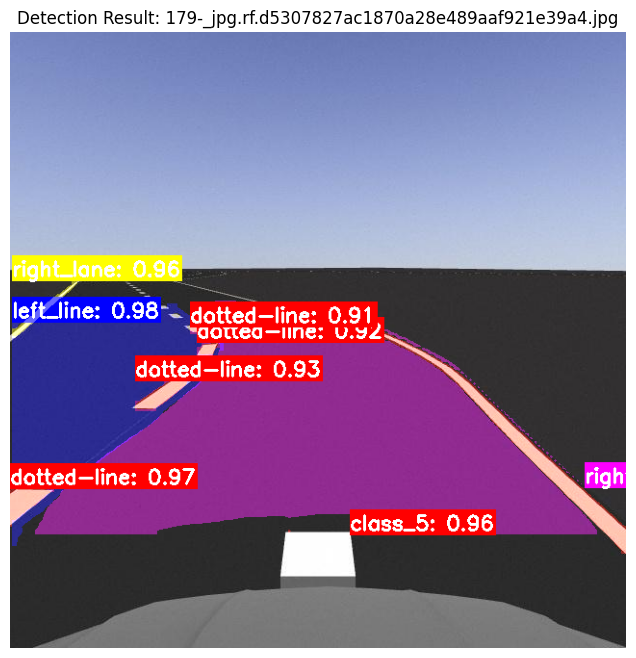

Results saved to /content/runs/detect/test_results12
16 labels saved to /content/runs/detect/test_results12/labels


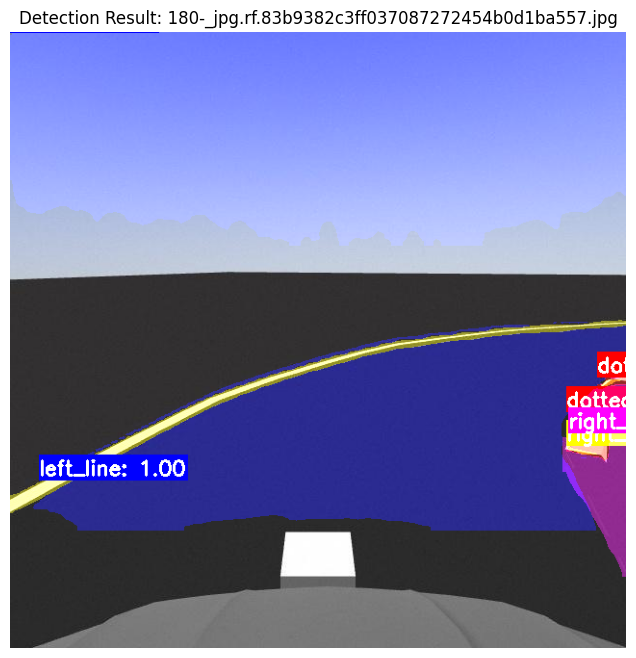

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

image_dir = '/content/dataset/test/images/'
test_images = sorted([img for img in os.listdir(image_dir) if img.lower().endswith(('.png', '.jpg', '.jpeg'))])


for i, img_name in enumerate(test_images[:16]):
    img_path = f'/content/dataset/test/images/{img_name}'

    # 예측 실행
    result = model.predict(img_path, conf=0.5, verbose=False)

    # 향상된 시각화
    enhanced_img = draw_enhanced_results(img_path, result)

    # 결과 표시
    plt.figure(figsize=(12, 8))
    plt.imshow(enhanced_img)
    plt.title(f'Detection Result: {img_name}')
    plt.axis('off')
    plt.show()



In [ ]:
import shutil
from google.colab import files

# 1. zip 파일로 압축 (기존 zip 파일이 있다면 덮어씌움)
shutil.make_archive('/content/runs_backup', 'zip', '/content/runs')

# 2. 다운로드 링크 제공
files.download('/content/runs_backup.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#동영상으로 만들기

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# YOLO 예측 + 시각화 함수 (콜라보용)
image_dir = '/content/dataset/test/images/'
test_images = sorted([img for img in os.listdir(image_dir) if img.lower().endswith(('.png', '.jpg', '.jpeg'))])

frames = []

for i, img_name in enumerate(test_images[:16]):
    img_path = os.path.join(image_dir, img_name)

    # 예측 실행
    result = model.predict(img_path, conf=0.5, verbose=False)

    # 향상된 시각화
    enhanced_img = draw_enhanced_results(img_path, result)

    # RGB -> BGR (OpenCV용)
    bgr_img = cv2.cvtColor(np.array(enhanced_img), cv2.COLOR_RGB2BGR)

    # 모든 프레임 사이즈를 동일하게 유지
    bgr_img = cv2.resize(bgr_img, (1280, 720))

    frames.append(bgr_img)

# 🔄 동영상 생성
video_path = "/content/detection_results.mp4"
fps = 2  # 0.5초 간격 = 2프레임/초
height, width, _ = frames[0].shape
fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # 코덱 설정

out = cv2.VideoWriter(video_path, fourcc, fps, (width, height))

for frame in frames:
    out.write(frame)

out.release()
print(f"✅ 영상 저장 완료: {video_path}")

# Colab에서 다운로드 링크 제공
from google.colab import files
files.download(video_path)

Results saved to /content/runs/detect/test_results12
16 labels saved to /content/runs/detect/test_results12/labels
Results saved to /content/runs/detect/test_results12
16 labels saved to /content/runs/detect/test_results12/labels
Results saved to /content/runs/detect/test_results12
16 labels saved to /content/runs/detect/test_results12/labels
Results saved to /content/runs/detect/test_results12
16 labels saved to /content/runs/detect/test_results12/labels
Results saved to /content/runs/detect/test_results12
16 labels saved to /content/runs/detect/test_results12/labels
✅ 영상 저장 완료: /content/detection_results.mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>